# VMD-LMH-BiLSTM: Bitcoin Price Prediction & Algorithmic Trading
---

```
Binance BTCUSDT Daily Klines
         ↓
  [Step 1] VMD Decomposition  →  11 sub-signals (Low / Medium / High freq)
         ↓
  [Step 2] BiLSTM Forecasting →  Predict next-day closing price
         ↓
  [Step 3] Evaluation + Algorithmic Trading vs Buy-and-Hold
```

## 1. Install & Import Dependencies

In [1]:
# ── Install (run once) ───────────────────────────────────────────────────────
import subprocess, sys

for pkg in ['vmdpy', 'tqdm', 'requests']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Dependencies ready')

Dependencies ready


In [2]:
import io, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
from datetime import datetime, timezone
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from vmdpy import VMD

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


---
## 2. Data Collection — Binance BTCUSDT Daily Klines

In [3]:
# ── Column definitions for Binance kline CSVs ────────────────────────────────
_KLINE_COLS = [
    'open_time', 'open', 'high', 'low', 'close', 'volume',
    'close_time', 'quote_volume', 'trades',
    'taker_buy_base', 'taker_buy_quote', 'ignore'
]

def _parse_one_month(raw: pd.DataFrame) -> pd.DataFrame:
    """Assign column names and cast types for a single monthly CSV."""
    raw.columns = _KLINE_COLS[:len(raw.columns)]
    df = raw.copy()
    ts = df['open_time'].astype(float)
    # Binance uses ms (13 digits); newer files may use us (16 digits) — detect automatically
    unit = 'us' if ts.iloc[0] > 1e14 else 'ms'
    df['timestamp'] = pd.to_datetime(ts, unit=unit, utc=True)
    for col in ['open', 'high', 'low', 'close', 'volume', 'quote_volume']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df['trades'] = pd.to_numeric(df.get('trades', np.nan), errors='coerce')
    return df


def fetch_klines(symbol_raw: str, interval: str, n_months: int) -> pd.DataFrame:
    BASE = "https://data.binance.vision/data/spot/monthly/klines"
    sym = symbol_raw.replace("/", "")

    today = datetime.now(timezone.utc)
    months, y, m = [], today.year, today.month
    for _ in range(n_months + 1):
        months.append(f"{y:04d}-{m:02d}")
        m -= 1
        if m == 0:
            m, y = 12, y - 1
    months = months[::-1]

    frames, skipped = [], []
    for ym in tqdm(months, desc="Downloading monthly ZIPs"):
        url = f"{BASE}/{sym}/{interval}/{sym}-{interval}-{ym}.zip"
        try:
            r = requests.get(url, timeout=60)
        except requests.RequestException as e:
            print(f"  [warn] network error for {ym}: {e}")
            skipped.append(ym); continue
        if r.status_code == 404 or not r.ok:
            skipped.append(ym); continue
        try:
            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                with z.open(z.namelist()[0]) as f:
                    raw = pd.read_csv(f, header=None, dtype=str)
        except zipfile.BadZipFile:
            print(f"  [warn] bad zip for {ym}, skipping")
            skipped.append(ym); continue
        frames.append(_parse_one_month(raw))

    if not frames:
        raise RuntimeError("No monthly files were downloaded.")
    if skipped:
        print(f"Skipped: {len(skipped)} month(s)")

    df = pd.concat(frames, ignore_index=True)
    keep = ["timestamp", "open", "high", "low", "close", "volume",
            "quote_volume", "trades"]
    df = df[[c for c in keep if c in df.columns]].dropna()
    df = (df.drop_duplicates("timestamp")
            .sort_values("timestamp")
            .reset_index(drop=True)
            .set_index("timestamp"))
    return df

In [4]:
# ── Download data ────────────────────────────────────────────────────────────
SYMBOL   = "BTCUSDT"
INTERVAL = "1d"       # daily candles (paper uses daily)
N_MONTHS = 72         # ~6 years of history (adjust as needed)

df_raw = fetch_klines(SYMBOL, INTERVAL, N_MONTHS)

print(f'\n Downloaded: {len(df_raw):,} rows')
print(f'   Period : {df_raw.index.min().date()} → {df_raw.index.max().date()}')
df_raw.tail(3)

Skipped: 1 month(s)

 Downloaded: 2,191 rows
   Period : 2020-05-01 → 2026-04-30


,open,high,low,close,volume,quote_volume,trades
timestamp,,,,,,,
2026-04-28 00:00:00+00:00,77371.32,77478.00,75666.60,76342.77,13210.72383,1.010413e+09,2352446
2026-04-29 00:00:00+00:00,76342.78,77904.93,74937.52,75780.00,18279.93022,1.399736e+09,3032890
2026-04-30 00:00:00+00:00,75780.00,76669.14,75323.65,76346.57,10381.81607,7.905846e+08,2569480


In [5]:
# ── Descriptive statistics (Table 1 in paper) ────────────────────────────────
from statsmodels.tsa.stattools import adfuller

close = df_raw['close']
adf_stat, adf_p, *_ = adfuller(close.dropna())

stats = close.agg(['count','mean','std','min','max','skew'])
print('\nDescriptive Statistics — BTCUSDT Close Price')
print('='*50)
for k, v in stats.items():
    print(f'  {k:<12}: {v:>14,.4f}')
print(f'  {"kurtosis":<12}: {close.kurtosis():>14,.4f}')
print(f'  {"ADF stat":<12}: {adf_stat:>14,.4f}  (p={adf_p:.4f})')
print('\n→ ADF p > 0.05 → non-stationary (unit root present)' if adf_p > 0.05
      else '\n→ ADF p ≤ 0.05 → stationary')


Descriptive Statistics — BTCUSDT Close Price
  count       :     2,191.0000
  mean        :    50,916.6623
  std         :    30,637.0978
  min         :     8,561.5200
  max         :   124,658.5400
  skew        :         0.5979
  kurtosis    :        -0.7053
  ADF stat    :        -1.3995  (p=0.5825)

→ ADF p > 0.05 → non-stationary (unit root present)


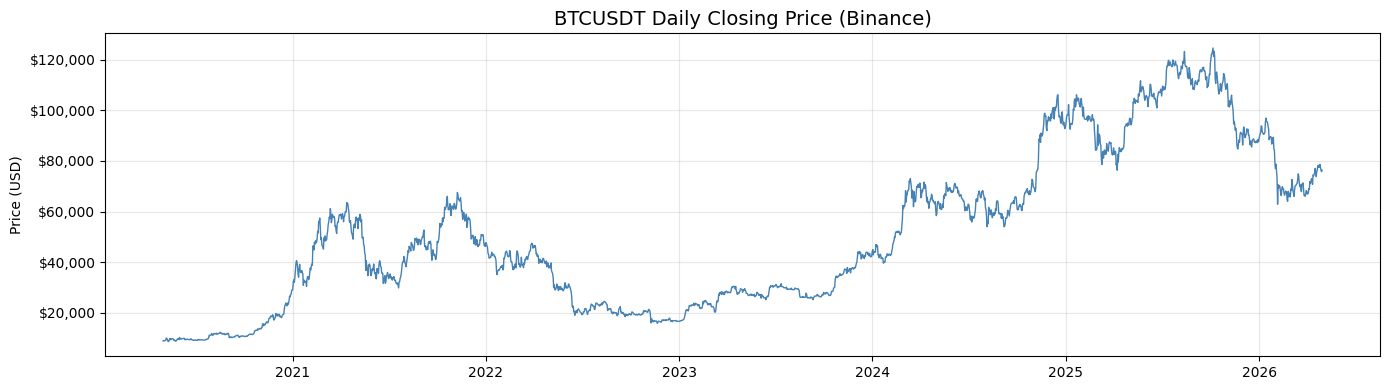

In [6]:
# ── Plot raw price ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_raw.index, df_raw['close'], linewidth=1, color='steelblue')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title(f'{SYMBOL} Daily Closing Price (Binance)', fontsize=14)
ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering

We add technical / on-chain proxy features as input alongside the VMD modes, mirroring the **macro-fundamental factors** used in the paper (Table 2).

In [7]:
df = df_raw.copy()

# Paper's Table 2 proxies
df['returns']      = df['close'].pct_change()               # daily return
df['volatility']   = df['returns'].rolling(7).std()         # 7-day rolling vol
df['ma_7']         = df['close'].rolling(7).mean()
df['ma_30']        = df['close'].rolling(30).mean()
df['ma_ratio']     = df['ma_7'] / df['ma_30']               # trend momentum
df['vol_ratio']    = df['volume'] / df['volume'].rolling(7).mean()  # volume surge
df['hl_range']     = (df['high'] - df['low']) / df['close'] # intraday range

# RSI(14) — investor sentiment proxy (replaces Google Trends)
delta              = df['close'].diff()
gain               = delta.clip(lower=0).rolling(14).mean()
loss               = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi']          = 100 - (100 / (1 + gain / loss.replace(0, 1e-9)))

df.dropna(inplace=True)

EXTRA_FEATURES = ['returns', 'volatility', 'ma_ratio', 'vol_ratio', 'hl_range', 'rsi']
df.shape
df[EXTRA_FEATURES].describe().round(4)

,returns,volatility,ma_ratio,vol_ratio,hl_range,rsi
count,2162.0000,2162.0000,2162.0000,2162.0000,2162.0000,2162.0000
mean,0.0014,0.0269,1.0122,1.0043,0.0444,52.9479
std,0.0303,0.0141,0.0779,0.3943,0.0308,17.4339
min,-0.1538,0.0032,0.7548,0.1826,0.0034,6.2892
25%,-0.0128,0.0172,0.9678,0.7361,0.0244,40.6661
50%,0.0003,0.0239,1.0041,0.9691,0.0371,51.7464
75%,0.0148,0.0338,1.0501,1.2095,0.0550,65.0934
max,0.1954,0.0976,1.3538,3.3644,0.3703,99.4267


---
## 4. Step 1 — Variational Mode Decomposition (VMD)

Decomposes the closing price into **K = 11** intrinsic mode functions, classified as:

| Group | Modes | Cycle | Interpretation |
|-------|-------|-------|----------------|
| **Low (L)** | M1 | ~years | Long-term macro trend |
| **Medium (M)** | M2–M4 | 3–8 months | Regulatory / political events |
| **High (H)** | M5–M11 | 4–21 days | Short-term investor speculation |

In [8]:
K     = 11      # number of modes (paper)
alpha = 2000    # bandwidth constraint
tau   = 0       # noise tolerance
DC    = False
init  = 1       # uniform omega initialisation
tol   = 1e-7

signal = df['close'].values.astype(float)

print('Running VMD — this may take ~30 seconds...')
u, u_hat, omega = VMD(signal, alpha, tau, K, DC, init, tol)
# u shape: (K, N)

mode_names = [f'M{i+1}' for i in range(K)]
modes_df   = pd.DataFrame(u.T, columns=mode_names, index=df.index)

LOW_MODES    = ['M1']
MEDIUM_MODES = ['M2', 'M3', 'M4']
HIGH_MODES   = [f'M{i}' for i in range(5, 12)]

print(f'VMD complete')
print(f'Low    (L): {LOW_MODES}')
print(f'Medium (M): {MEDIUM_MODES}')
print(f'High   (H): {HIGH_MODES}')

Running VMD — this may take ~30 seconds...
VMD complete
Low    (L): ['M1']
Medium (M): ['M2', 'M3', 'M4']
High   (H): ['M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'M11']


In [9]:
# ── Compute dominant cycle per mode via FFT ──────────────────────────────────
from numpy.fft import fft, fftfreq

print('Mode  | Dom. Freq | Cycle (days) | Group')
print('-'*50)
for i, name in enumerate(mode_names):
    freqs  = fftfreq(len(signal), d=1)
    amps   = np.abs(fft(u[i]))
    pos    = freqs > 0
    dom_f  = freqs[pos][np.argmax(amps[pos])]
    cycle  = 1 / dom_f if dom_f > 0 else np.inf
    grp    = 'Low' if name in LOW_MODES else ('Medium' if name in MEDIUM_MODES else 'High')
    print(f'{name:>5} | {dom_f:>9.5f} | {cycle:>12.1f} | {grp}')

Mode  | Dom. Freq | Cycle (days) | Group
--------------------------------------------------
   M1 |   0.00046 |       2162.0 | Low
   M2 |   0.00370 |        270.2 | Medium
   M3 |   0.01203 |         83.2 | Medium
   M4 |   0.03654 |         27.4 | Medium
   M5 |   0.05227 |         19.1 | High
   M6 |   0.07401 |         13.5 | High
   M7 |   0.12442 |          8.0 | High
   M8 |   0.19611 |          5.1 | High
   M9 |   0.29741 |          3.4 | High
  M10 |   0.38205 |          2.6 | High
  M11 |   0.45328 |          2.2 | High


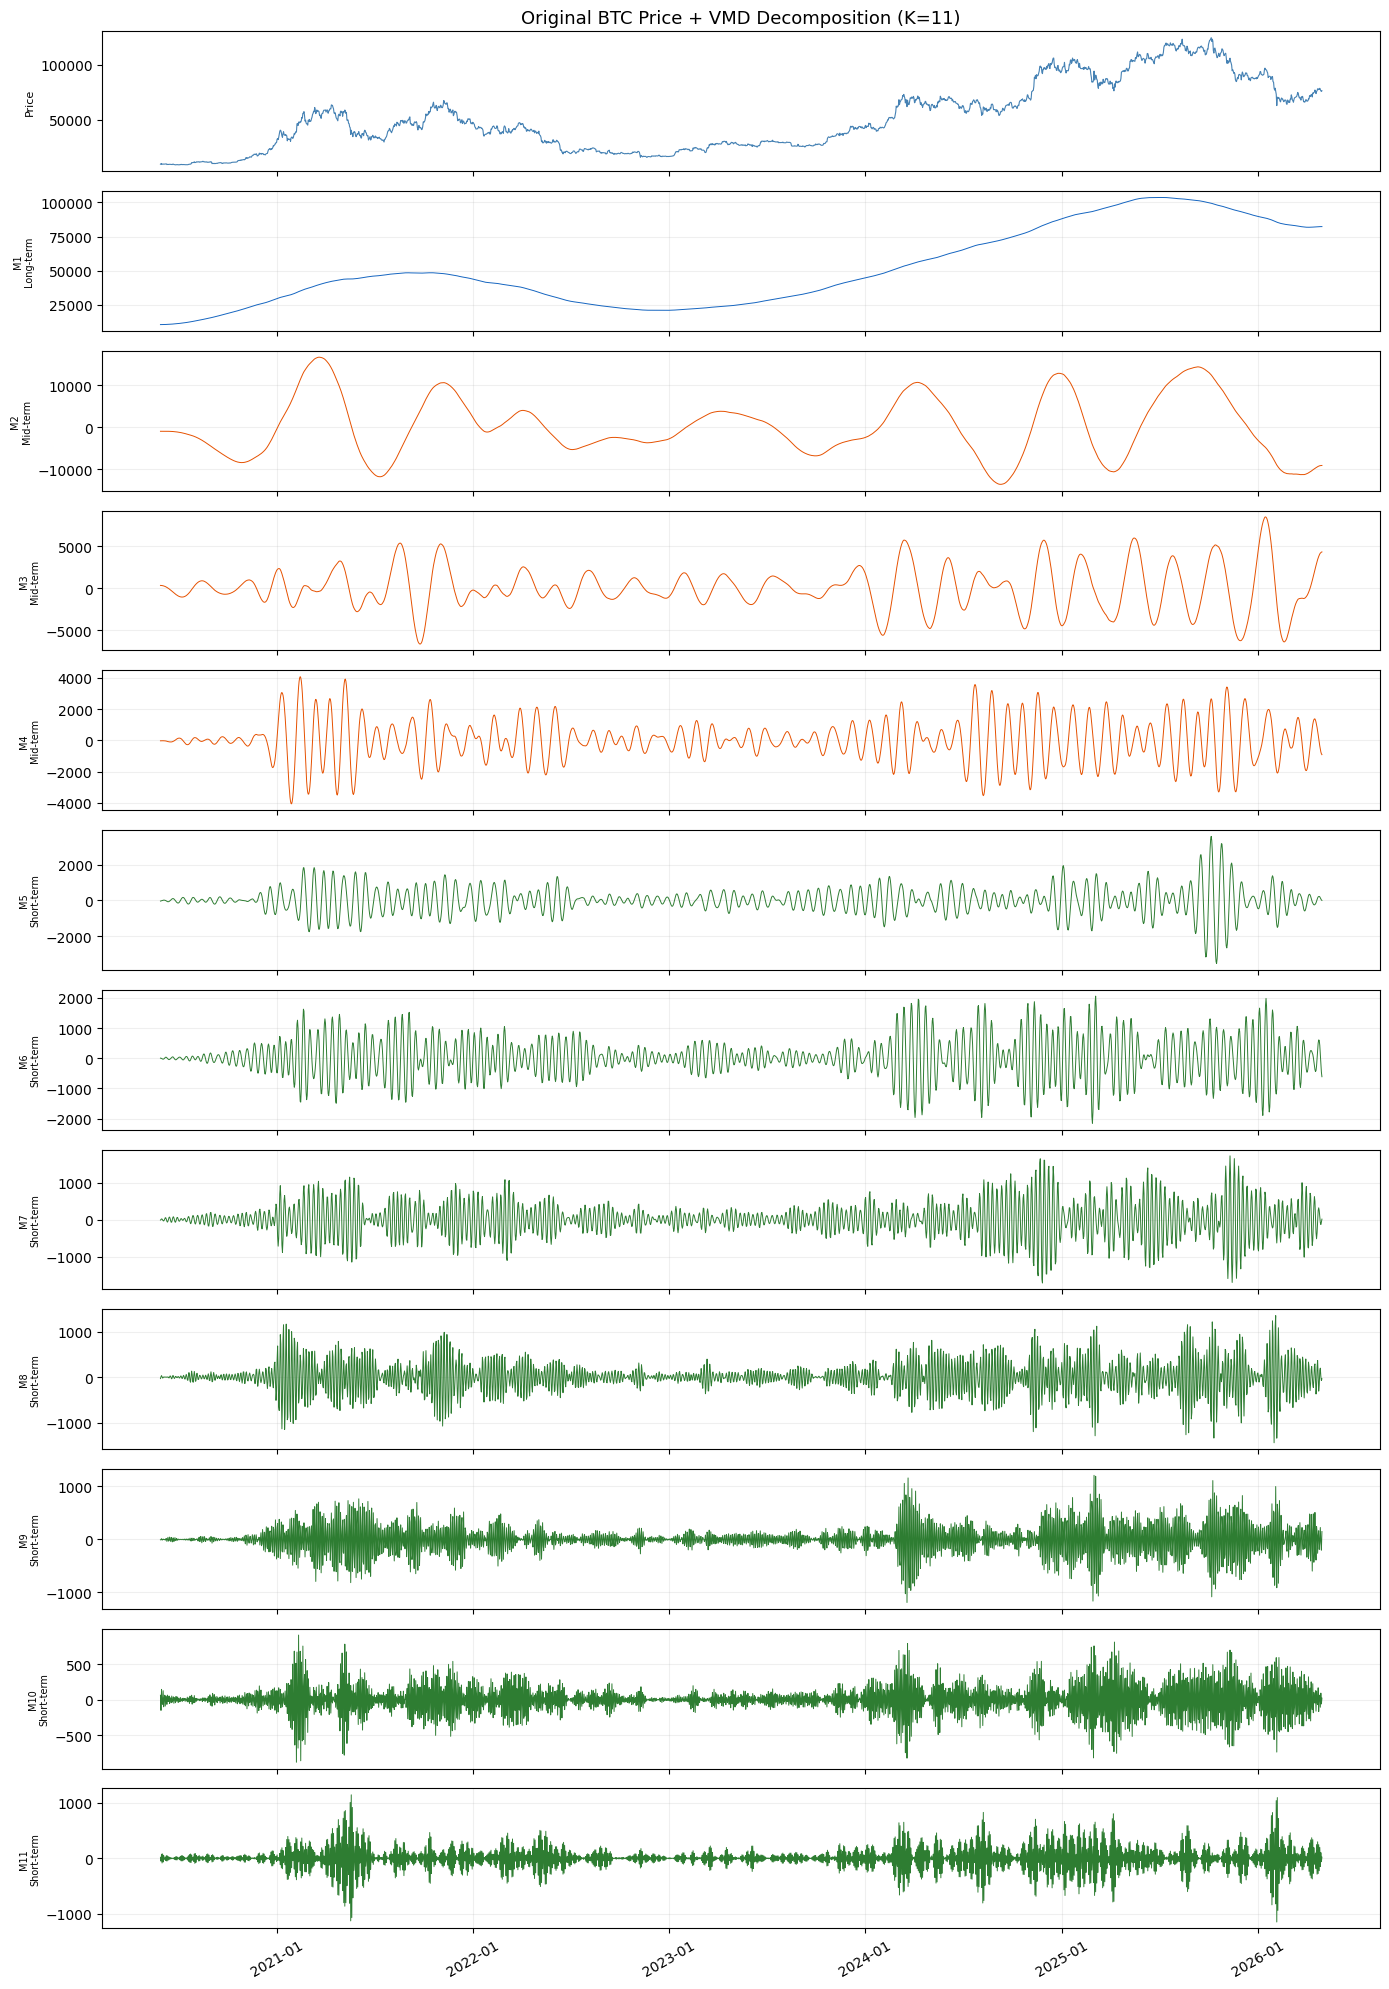

Figure saved - vmd_modes.png


In [10]:
# ── Visualise all VMD modes ───────────────────────────────────────────────────
fig, axes = plt.subplots(K + 1, 1, figsize=(14, 20), sharex=True)
axes[0].plot(df.index, signal, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Price', fontsize=8)
axes[0].set_title('Original BTC Price + VMD Decomposition (K=11)', fontsize=13)

palette = ['#1565C0'] + ['#E65100']*3 + ['#2E7D32']*7
groups  = ['Long-term'] + ['Mid-term']*3 + ['Short-term']*7

for i in range(K):
    axes[i+1].plot(df.index, u[i], color=palette[i], linewidth=0.7)
    axes[i+1].set_ylabel(f'M{i+1}\n{groups[i]}', fontsize=7)
    axes[i+1].grid(alpha=0.2)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.savefig('vmd_modes.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved - vmd_modes.png')

---
## 5. Dataset Preparation — Sliding-Window Sequences

- **Window N = 25** (best found in paper)  
- **Train / Test = 90% / 10%**  
- Input = 11 VMD modes + 6 technical features  
- Target = normalised next-day close price

In [11]:
WINDOW    = 25
TRAIN_PCT = 0.90

# ── Build feature matrix ─────────────────────────────────────────────────────
X_raw = np.hstack([
    modes_df.values,                  # (N, 11) VMD modes
    df[EXTRA_FEATURES].values         # (N,  6) technical
])  # shape: (N, 17)

y_raw = df['close'].values.reshape(-1, 1)   # target

# ── Min-Max normalisation (0-1) ───────────────────────────────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw).flatten()

# ── Sliding-window sequences ─────────────────────────────────────────────────
def make_sequences(X, y, window):
    xs, ys = [], []
    for i in range(window, len(X)):
        xs.append(X[i - window:i])
        ys.append(y[i])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, WINDOW)

split = int(len(X_seq) * TRAIN_PCT)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

test_index = df.index[WINDOW + split:WINDOW + split + len(y_test)]

print(f'Feature dims   : {X_seq.shape[2]}')
print(f'Train sequences: {X_train.shape}')
print(f'Test  sequences: {X_test.shape}')
print(f'Test  period   : {test_index[0].date()} to {test_index[-1].date()}')

# Torch tensors
X_tr = torch.from_numpy(X_train)
y_tr = torch.from_numpy(y_train).unsqueeze(1)
X_te = torch.from_numpy(X_test)
y_te = torch.from_numpy(y_test).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)

Feature dims   : 17
Train sequences: (1923, 25, 17)
Test  sequences: (214, 25, 17)
Test  period   : 2025-09-29 to 2026-04-30


---
## 6. Step 2 — Bidirectional LSTM Architecture

Architecture from paper (Section Bidirectional LSTM):  
`Input → [Forward LSTM + Backward LSTM] → Fully-Connected (1 node)`  
Optimizer: **Adam**, Activation: **tanh**

In [12]:
class BiLSTM(nn.Module):
    """
    Bidirectional LSTM as described in Li et al. (2022).
    Two hidden layers — one processing the sequence forward,
    one backward — both connected to a single output node.
    """
    def __init__(self, input_size: int,
                 hidden_size: int = 128,
                 num_layers: int  = 2,
                 dropout: float   = 0.2):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x : (batch, seq_len, input_size)
        out, _ = self.bilstm(x)    # (batch, seq_len, hidden*2)
        return self.fc(out[:, -1]) # last time-step → scalar


INPUT_DIM = X_tr.shape[2]
model     = BiLSTM(input_size=INPUT_DIM).to(DEVICE)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

BiLSTM(
  (bilstm): LSTM(17, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): Tanh()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 562,305


In [13]:
# ── Training ─────────────────────────────────────────────────────────────────
EPOCHS = 100
LR     = 1e-3

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=10, factor=0.5)

X_te_d = X_te.to(DEVICE)
y_te_d = y_te.to(DEVICE)

train_losses, val_losses = [], []
best_val, best_state = float('inf'), None

for epoch in range(1, EPOCHS + 1):
    # ── train ──
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    # ── validate ──
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_te_d), y_te_d).item()

    train_losses.append(np.mean(batch_losses))
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val   = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'train_loss={train_losses[-1]:.6f}  '
              f'val_loss={val_loss:.6f}')

model.load_state_dict(best_state)

Epoch  10/100  train_loss=0.000999  val_loss=0.002443
Epoch  20/100  train_loss=0.000770  val_loss=0.000221
Epoch  30/100  train_loss=0.000682  val_loss=0.001013
Epoch  40/100  train_loss=0.000636  val_loss=0.000157
Epoch  50/100  train_loss=0.000557  val_loss=0.005236
Epoch  60/100  train_loss=0.000557  val_loss=0.000656
Epoch  70/100  train_loss=0.000475  val_loss=0.000051
Epoch  80/100  train_loss=0.000489  val_loss=0.000109
Epoch  90/100  train_loss=0.000481  val_loss=0.000048
Epoch 100/100  train_loss=0.000579  val_loss=0.000139


<All keys matched successfully>

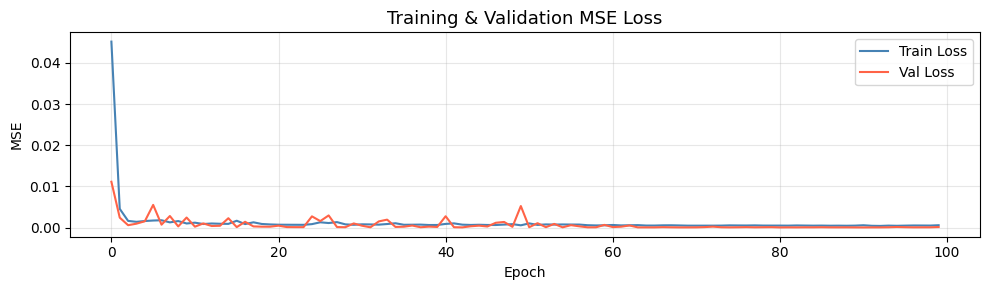

In [14]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(train_losses, label='Train Loss', color='steelblue')
ax.plot(val_losses,   label='Val Loss',   color='tomato')
ax.set_title('Training & Validation MSE Loss', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=120)
plt.show()

---
## 7. Evaluation — Forecasting Performance

Metrics from paper Table 3: **RMSE, MAPE, MAE, DA (Directional Accuracy)**

In [15]:
model.eval()
with torch.no_grad():
    preds_s = model(X_te.to(DEVICE)).cpu().numpy()

preds_usd  = scaler_y.inverse_transform(preds_s).flatten()
actual_usd = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# ── Metric functions ─────────────────────────────────────────────────────────
def rmse(a, p): return np.sqrt(mean_squared_error(a, p))
def mape(a, p): return float(np.mean(np.abs((a - p) / (np.abs(a) + 1e-9))))
def mae_(a, p): return float(mean_absolute_error(a, p))
def da(a, p):   # Eq. 16 in paper
    actual_dir = np.sign(np.diff(a))
    pred_dir   = np.sign(np.diff(p))
    return float(np.mean(actual_dir == pred_dir))

metrics = dict(
    RMSE=rmse(actual_usd, preds_usd),
    MAPE=mape(actual_usd, preds_usd),
    MAE =mae_(actual_usd, preds_usd),
    DA  =da(actual_usd, preds_usd)
)

print('='*45)
print('  VMD-LMH-BiLSTM — Test Set Performance')
print('='*45)
for k, v in metrics.items():
    print(f'  {k:<6}: {v:>10.4f}')
print('='*45)

  VMD-LMH-BiLSTM — Test Set Performance
  RMSE  :   738.6719
  MAPE  :     0.0069
  MAE   :   585.1952
  DA    :     0.8263


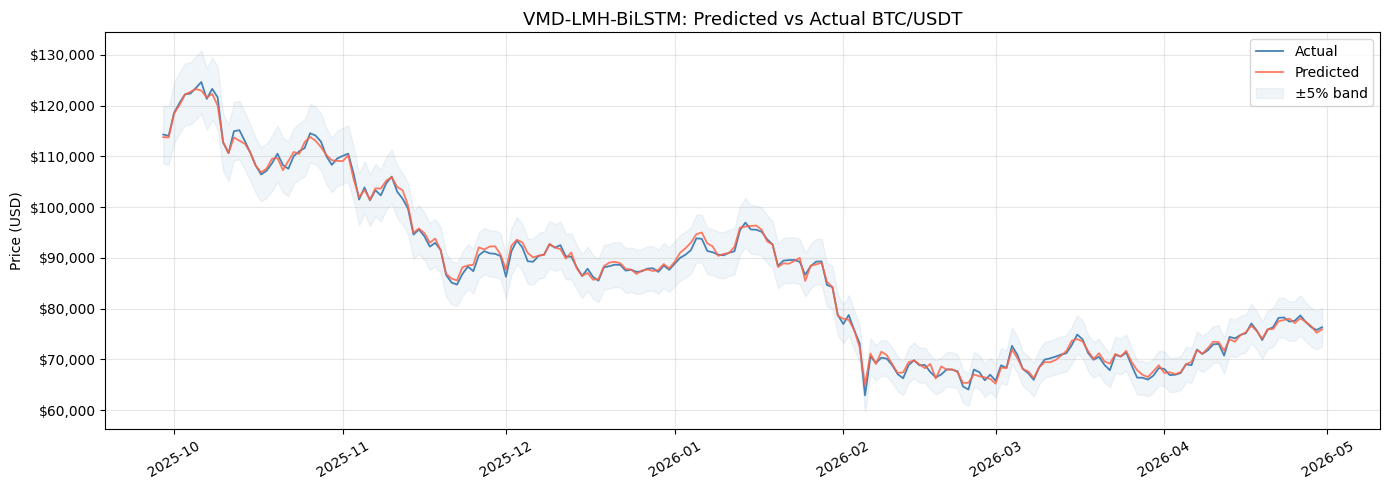

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_index, actual_usd, label='Actual',    color='steelblue', linewidth=1.3)
ax.plot(test_index, preds_usd,  label='Predicted', color='tomato',    linewidth=1.3, alpha=0.85)
ax.fill_between(test_index,
                actual_usd * 0.95, actual_usd * 1.05,
                alpha=0.08, color='steelblue', label='±5% band')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('VMD-LMH-BiLSTM: Predicted vs Actual BTC/USDT', fontsize=13)
ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(); ax.grid(alpha=0.3)
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig('prediction_result.png', dpi=120)
plt.show()

---
## 8. Benchmark Comparison (Table 3 in paper)

We compare against a **plain BiLSTM** (no VMD) and a **Naïve** last-value baseline.

In [17]:
# ── Naïve (last-value) ────────────────────────────────────────────────────────
naive_m = dict(
    RMSE=rmse(actual_usd[1:], actual_usd[:-1]),
    MAPE=mape(actual_usd[1:], actual_usd[:-1]),
    MAE =mae_(actual_usd[1:], actual_usd[:-1]),
    DA  =da(actual_usd[1:], actual_usd[:-1])
)

# ── Plain BiLSTM (no VMD, only EXTRA_FEATURES) ────────────────────────────────
Xp_scaled = MinMaxScaler().fit_transform(df[EXTRA_FEATURES].values)
Xp_seq, _ = make_sequences(Xp_scaled, y_scaled, WINDOW)
Xp_tr = torch.from_numpy(Xp_seq[:split]).to(DEVICE)
Xp_te = torch.from_numpy(Xp_seq[split:]).to(DEVICE)
Yp_tr = torch.from_numpy(y_train).unsqueeze(1).to(DEVICE)

plain_model = BiLSTM(input_size=len(EXTRA_FEATURES)).to(DEVICE)
plain_opt   = torch.optim.Adam(plain_model.parameters(), lr=1e-3)
plain_ld    = DataLoader(TensorDataset(Xp_tr, Yp_tr), batch_size=64, shuffle=True)

print('Training plain BiLSTM (no VMD)...')
for ep in range(EPOCHS):
    plain_model.train()
    for xb, yb in plain_ld:
        plain_opt.zero_grad()
        criterion(plain_model(xb), yb).backward()
        nn.utils.clip_grad_norm_(plain_model.parameters(), 1.0)
        plain_opt.step()

plain_model.eval()
with torch.no_grad():
    plain_p = plain_model(Xp_te).cpu().numpy()
plain_usd = scaler_y.inverse_transform(plain_p).flatten()
n = min(len(actual_usd), len(plain_usd))

plain_m = dict(
    RMSE=rmse(actual_usd[:n], plain_usd[:n]),
    MAPE=mape(actual_usd[:n], plain_usd[:n]),
    MAE =mae_(actual_usd[:n], plain_usd[:n]),
    DA  =da(actual_usd[:n], plain_usd[:n])
)

# ── Print comparison table ────────────────────────────────────────────────────
print()
header = f'{"Model":<26} {"RMSE":>9} {"MAPE":>8} {"MAE":>10} {"DA":>8}'
print('='*65)
print(header)
print('-'*65)
for name, m in [('VMD-LMH-BiLSTM (paper)', metrics),
                ('BiLSTM (no VMD)',          plain_m),
                ('Naïve (last value)',        naive_m)]:
    print(f'{name:<26} {m["RMSE"]:>9,.2f} {m["MAPE"]:>8.4f} {m["MAE"]:>10,.2f} {m["DA"]:>8.4f}')
print('='*65)

Training plain BiLSTM (no VMD)...

Model                           RMSE     MAPE        MAE       DA
-----------------------------------------------------------------
VMD-LMH-BiLSTM (paper)        738.67   0.0069     585.20   0.8263
BiLSTM (no VMD)            41,653.06   0.3856  33,940.04   0.5822
Naïve (last value)          2,141.98   0.0183   1,546.69   0.5519


---
## 9. Step 3 — Algorithmic Trading Simulation

Signal rules from paper Section 'Trading results comparisons':  
- **BUY** if pred(t+1) > price(t)  
- **SELL** if pred(t+1) < price(t)  
- **HOLD** otherwise  

Initial capital: **$100,000** | Binance taker fee: **0.1%**

In [18]:
def simulate_trading(actual: np.ndarray,
                     predicted: np.ndarray,
                     capital: float = 100_000,
                     fee: float = 0.001) -> pd.DataFrame:
    cash, btc = capital, 0.0
    rows = []
    for i in range(len(actual) - 1):
        today, pred_next = actual[i], predicted[i]
        tomorrow         = actual[i + 1]

        if pred_next > today and cash > 0:
            btc  = cash * (1 - fee) / today
            cash = 0.0
            action = 'BUY'
        elif pred_next < today and btc > 0:
            cash = btc * today * (1 - fee)
            btc  = 0.0
            action = 'SELL'
        else:
            action = 'HOLD'

        rows.append({'portfolio': cash + btc * tomorrow,
                     'action': action, 'price': tomorrow})
    return pd.DataFrame(rows)


def annualized_return(final, initial, n_days):
    return ((final / initial) ** (365.0 / n_days) - 1) * 100


CAPITAL = 100_000
n       = min(len(actual_usd), len(preds_usd))

res_vmd   = simulate_trading(actual_usd[:n], preds_usd[:n],   CAPITAL)
res_plain = simulate_trading(actual_usd[:n], plain_usd[:n],   CAPITAL)

# Buy-and-hold
bnh = (CAPITAL / actual_usd[0]) * actual_usd[1:n]

ar_vmd   = annualized_return(res_vmd['portfolio'].iloc[-1],   CAPITAL, n)
ar_plain = annualized_return(res_plain['portfolio'].iloc[-1], CAPITAL, n)
ar_bnh   = annualized_return(bnh[-1],                         CAPITAL, n)

print('='*56)
print(f'{"Strategy":<24} {"Final Capital":>16}  {"Ann. Return":>10}')
print('-'*56)
for name, final, ar in [
    ('VMD-LMH-BiLSTM',  res_vmd['portfolio'].iloc[-1],   ar_vmd),
    ('Plain BiLSTM',    res_plain['portfolio'].iloc[-1], ar_plain),
    ('Buy & Hold',      bnh[-1],                         ar_bnh),
]:
    print(f'{name:<24} ${final:>14,.0f}  {ar:>+10.1f}%')
print('='*56)

Strategy                    Final Capital  Ann. Return
--------------------------------------------------------
VMD-LMH-BiLSTM           $       152,048      +104.4%
Plain BiLSTM             $        86,698       -21.6%
Buy & Hold               $        66,788       -49.8%


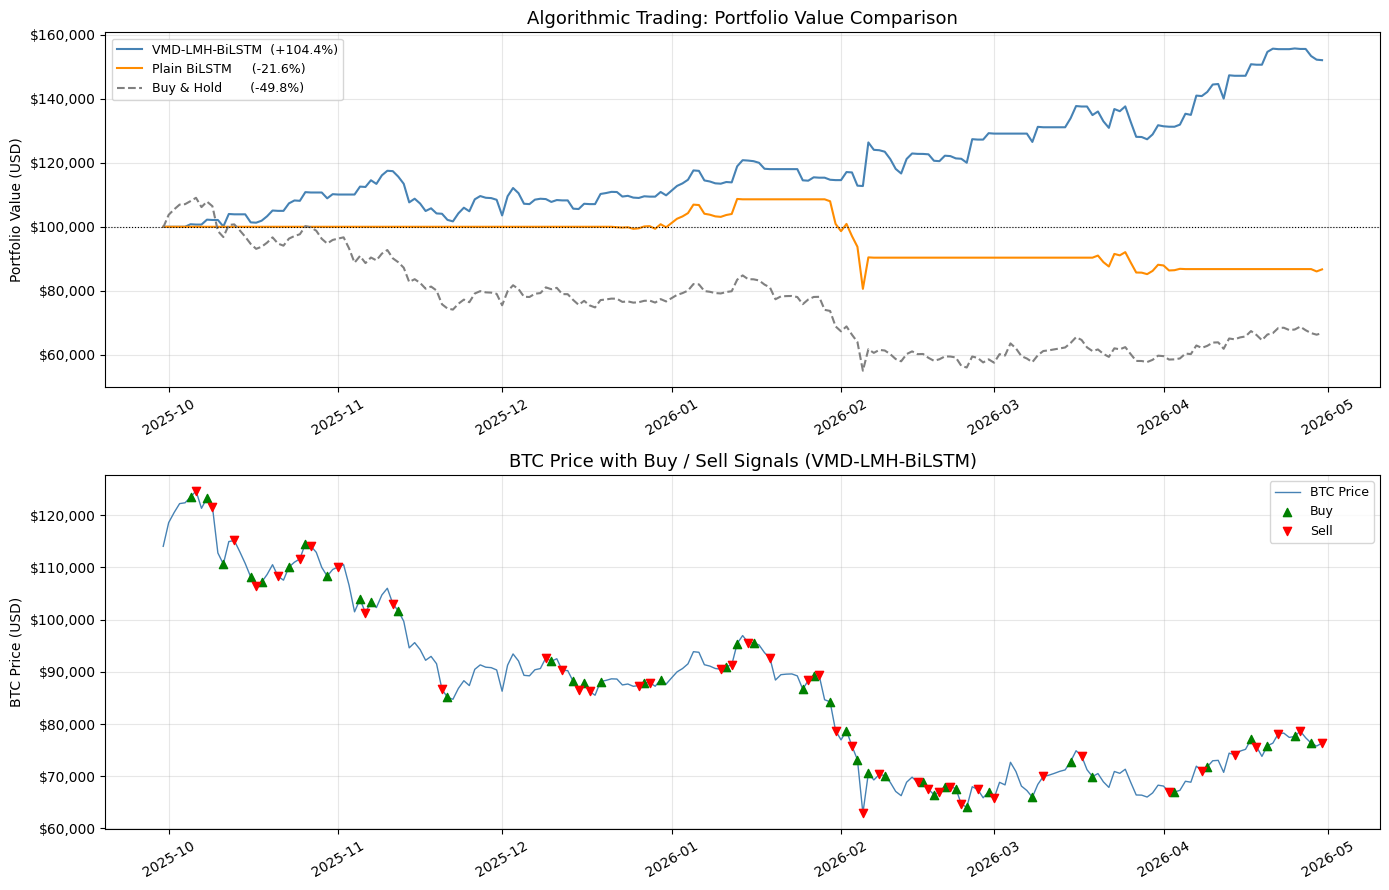

In [19]:
trade_idx = test_index[1:len(res_vmd)+1]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ── Portfolio value ───────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(trade_idx[:len(res_vmd)],   res_vmd['portfolio'],   color='steelblue',  lw=1.5, label=f'VMD-LMH-BiLSTM  ({ar_vmd:+.1f}%)')
ax.plot(trade_idx[:len(res_plain)], res_plain['portfolio'], color='darkorange', lw=1.5, label=f'Plain BiLSTM     ({ar_plain:+.1f}%)')
ax.plot(trade_idx[:len(bnh)],       bnh,                    color='grey',       lw=1.5, linestyle='--', label=f'Buy & Hold       ({ar_bnh:+.1f}%)')
ax.axhline(CAPITAL, color='black', linestyle=':', lw=0.8)
ax.set_title('Algorithmic Trading: Portfolio Value Comparison', fontsize=13)
ax.set_ylabel('Portfolio Value (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Price + signals ───────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(trade_idx[:len(res_vmd)], res_vmd['price'], color='steelblue', lw=1, label='BTC Price')
buys  = res_vmd.index[res_vmd['action'] == 'BUY'].tolist()
sells = res_vmd.index[res_vmd['action'] == 'SELL'].tolist()
if buys:
    ax2.scatter(trade_idx[buys],  res_vmd.loc[buys,  'price'], marker='^', color='green', s=35, zorder=5, label='Buy')
if sells:
    ax2.scatter(trade_idx[sells], res_vmd.loc[sells, 'price'], marker='v', color='red',   s=35, zorder=5, label='Sell')
ax2.set_title('BTC Price with Buy / Sell Signals (VMD-LMH-BiLSTM)', fontsize=13)
ax2.set_ylabel('BTC Price (USD)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

for a in axes:
    a.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(a.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('trading_performance.png', dpi=120)
plt.show()

---
## 10. Frequency-Mode Ablation Study (Table 4 in paper)

Trains one model per frequency configuration to show that **using all three groups (LMH) together is optimal**.

In [20]:
def run_config(mode_list: list, label: str, epochs: int = 60) -> dict:
    Xc = np.hstack([modes_df[mode_list].values,
                    df[EXTRA_FEATURES].values])
    Xc_sc = MinMaxScaler().fit_transform(Xc)
    Xs, _ = make_sequences(Xc_sc, y_scaled, WINDOW)

    sp  = int(len(Xs) * TRAIN_PCT)
    Xtr = torch.from_numpy(Xs[:sp]).to(DEVICE)
    Xte = torch.from_numpy(Xs[sp:]).to(DEVICE)
    Ytr = torch.from_numpy(y_seq[:sp]).unsqueeze(1).to(DEVICE)

    m   = BiLSTM(input_size=Xs.shape[2], hidden_size=64).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    ld  = DataLoader(TensorDataset(Xtr, Ytr), batch_size=64, shuffle=True)

    for _ in range(epochs):
        m.train()
        for xb, yb in ld:
            opt.zero_grad(); criterion(m(xb), yb).backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()

    m.eval()
    with torch.no_grad():
        p = m(Xte).cpu().numpy()
    p_usd = scaler_y.inverse_transform(p).flatten()
    a_usd = actual_usd[:len(p_usd)]
    return {'Model': label,
            'RMSE': rmse(a_usd, p_usd), 'MAPE': mape(a_usd, p_usd),
            'MAE':  mae_(a_usd, p_usd), 'DA':   da(a_usd, p_usd)}


configs = [
    (LOW_MODES,                         'L-BiLSTM'),
    (MEDIUM_MODES,                      'M-BiLSTM'),
    (HIGH_MODES,                        'H-BiLSTM'),
    (LOW_MODES + MEDIUM_MODES,          'LM-BiLSTM'),
    (LOW_MODES + HIGH_MODES,            'LH-BiLSTM'),
    (MEDIUM_MODES + HIGH_MODES,         'MH-BiLSTM'),
    (LOW_MODES + MEDIUM_MODES + HIGH_MODES, 'LMH-BiLSTM ✓'),
]

print('Running ablation study (7 configs × 60 epochs)...')
ablation = [run_config(m, l) for m, l in tqdm(configs)]
abl_df = pd.DataFrame(ablation).set_index('Model')
print()
print(abl_df.round(4).to_string())

Running ablation study (7 configs × 60 epochs)...


100%|██████████| 7/7 [01:01<00:00,  8.78s/it]


                    RMSE    MAPE         MAE      DA
Model                                               
L-BiLSTM       6994.6674  0.0649   5720.6528  0.5493
M-BiLSTM      26075.2842  0.2458  21662.9277  0.5493
H-BiLSTM      20932.2587  0.2134  17281.4238  0.5258
LM-BiLSTM      2815.4765  0.0243   2173.4014  0.6009
LH-BiLSTM      8260.3927  0.0671   6308.4292  0.7700
MH-BiLSTM     22239.8763  0.2110  17749.7480  0.6197
LMH-BiLSTM ✓   4247.9998  0.0453   3995.9275  0.8263


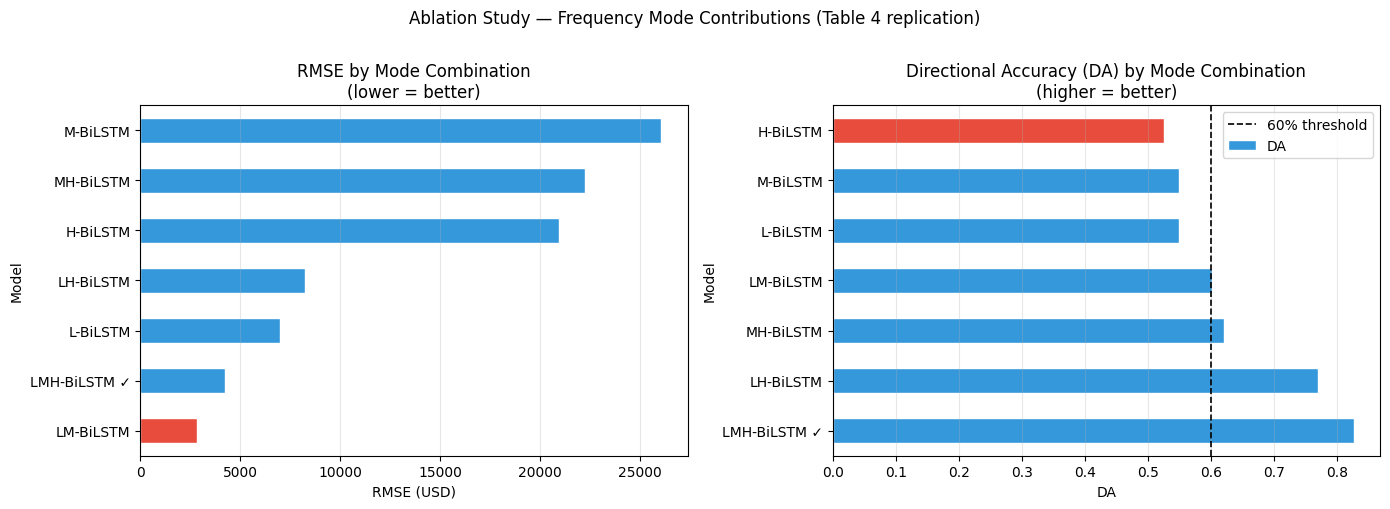

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if 'LMH' in i else '#3498db' for i in abl_df.index]

abl_df['RMSE'].sort_values().plot.barh(ax=axes[0], color=colors[::-1], edgecolor='white')
axes[0].set_title('RMSE by Mode Combination\n(lower = better)', fontsize=12)
axes[0].set_xlabel('RMSE (USD)')
axes[0].grid(alpha=0.3, axis='x')

abl_df['DA'].sort_values(ascending=False).plot.barh(ax=axes[1], color=colors, edgecolor='white')
axes[1].axvline(0.60, color='black', linestyle='--', lw=1.2, label='60% threshold')
axes[1].set_title('Directional Accuracy (DA) by Mode Combination\n(higher = better)', fontsize=12)
axes[1].set_xlabel('DA')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Ablation Study — Frequency Mode Contributions (Table 4 replication)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=120)
plt.show()

---
## 11. Save Model & Final Summary

In [22]:
torch.save(model.state_dict(), 'vmd_bilstm_btcusdt.pt')
print('✅ Model weights saved → vmd_bilstm_btcusdt.pt')

print('\n' + '='*55)
print('  FINAL RESULTS — VMD-LMH-BiLSTM on BTCUSDT')
print('='*55)
print(f'  Test period     : {test_index[0].date()} → {test_index[-1].date()}')
print(f'  RMSE            : ${metrics["RMSE"]:,.2f}')
print(f'  MAPE            : {metrics["MAPE"]*100:.2f}%')
print(f'  MAE             : ${metrics["MAE"]:,.2f}')
print(f'  Dir. Accuracy   : {metrics["DA"]*100:.2f}%')
print('-'*55)
print(f'  Algo return     : {ar_vmd:+.1f}%  (annualised)')
print(f'  Buy & Hold      : {ar_bnh:+.1f}%  (annualised)')
print(f'  Outperformance  : {ar_vmd - ar_bnh:+.1f}%')
print('='*55)

✅ Model weights saved → vmd_bilstm_btcusdt.pt

  FINAL RESULTS — VMD-LMH-BiLSTM on BTCUSDT
  Test period     : 2025-09-29 → 2026-04-30
  RMSE            : $738.67
  MAPE            : 0.69%
  MAE             : $585.20
  Dir. Accuracy   : 82.63%
-------------------------------------------------------
  Algo return     : +104.4%  (annualised)
  Buy & Hold      : -49.8%  (annualised)
  Outperformance  : +154.1%
